#Data Loading and Extraction

In [ ]:
import zipfile
import os
import pandas as pd

# Define the zip file path
zip_path = "/content/Datasets1.zip"
unzip_dir = "./datasets"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

# List files in the extracted directory
files = os.listdir(unzip_dir)
print(f"Number of files: {len(files)}")
print("Files:", files)

# Display the head of each CSV file
for file in files:
    file_path = os.path.join(unzip_dir, file)
    if file.endswith(".csv"):
        df = pd.read_csv(file_path)
        print(f"\nHead of {file}:")
        print(df.head())

Number of files: 3
Files: ['test.csv', 'ideal.csv', 'train.csv']

Head of test.csv:
      x          y
0  17.5  34.161040
1   0.3   1.215102
2  -8.7 -16.843908
3 -19.2 -37.170870
4 -11.0 -20.263054

Head of ideal.csv:
      x        y1        y2        y3        y4        y5        y6        y7  \
0 -20.0 -0.912945  0.408082  9.087055  5.408082 -9.087055  0.912945 -0.839071   
1 -19.9 -0.867644  0.497186  9.132356  5.497186 -9.132356  0.867644 -0.865213   
2 -19.8 -0.813674  0.581322  9.186326  5.581322 -9.186326  0.813674 -0.889191   
3 -19.7 -0.751573  0.659649  9.248426  5.659649 -9.248426  0.751573 -0.910947   
4 -19.6 -0.681964  0.731386  9.318036  5.731386 -9.318036  0.681964 -0.930426   

         y8        y9  ...        y41        y42       y43       y44  \
0 -0.850919  0.816164  ... -40.456474  40.204040  2.995732 -0.008333   
1  0.168518  0.994372  ... -40.233820  40.048590  2.990720 -0.008340   
2  0.612391  1.162644  ... -40.006836  39.890660  2.985682 -0.008347   
3 -0.99

#Loading files into a database

In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine

# Define paths
dataset_dir = "/content/datasets"
db_path = "sqlite:///datasets.db"

# Create SQLite database engine
engine = create_engine(db_path)

# File names to load
files = {
    "train": "train.csv",
    "ideal": "ideal.csv",
    "test": "test.csv"
}

# Load CSV files into database
for table_name, file_name in files.items():
    file_path = os.path.join(dataset_dir, file_name)
    df = pd.read_csv(file_path)
    df.to_sql(table_name, engine, if_exists='replace', index=False)
    print(f"Saved {file_name} to database as table '{table_name}'")

print("Database setup complete.")

Saved train.csv to database as table 'train'
Saved ideal.csv to database as table 'ideal'
Saved test.csv to database as table 'test'
Database setup complete.


#Identifying the best-fitting ideal functions using the least squares method

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np

# Define database path
db_path = "sqlite:///datasets.db"
engine = create_engine(db_path)

# Load training data and ideal functions from the database
train_df = pd.read_sql("SELECT * FROM train", engine)
ideal_df = pd.read_sql("SELECT * FROM ideal", engine)

# Drop the 'x' column for calculations
train_x = train_df["x"]
train_y = train_df.drop(columns=["x"])
ideal_x = ideal_df["x"]
ideal_y = ideal_df.drop(columns=["x"])

# Dictionary to store the best ideal functions for each training function
best_ideal_functions = {}

# Find the best-fitting ideal function for each training function
for train_col in train_y.columns:
    min_error = float("inf")
    best_fit = None

    for ideal_col in ideal_y.columns:
        error = np.sum((train_y[train_col] - ideal_y[ideal_col]) ** 2)

        if error < min_error:
            min_error = error
            best_fit = ideal_col

    best_ideal_functions[train_col] = best_fit
    print(f"Best ideal function for {train_col}: {best_fit} with error {min_error}")

# Save best matches to a DataFrame and store in the database
best_fit_df = pd.DataFrame(list(best_ideal_functions.items()), columns=["Training Function", "Best Ideal Function"])
best_fit_df.to_sql("best_ideal_functions", engine, if_exists='replace', index=False)

print("Best-fitting ideal functions identified and saved.")

Best ideal function for y1: y42 with error 34.246594303368504
Best ideal function for y2: y41 with error 35.60184692481152
Best ideal function for y3: y11 with error 29.86183029016382
Best ideal function for y4: y48 with error 31.963434327891697
Best-fitting ideal functions identified and saved.


#Mapping Test Data to Ideal Functions

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Define database path
db_path = "sqlite:///datasets.db"
engine = create_engine(db_path)

# Load required data from the database
test_df = pd.read_sql("SELECT * FROM test", engine)
best_ideal_df = pd.read_sql("SELECT * FROM best_ideal_functions", engine)
ideal_df = pd.read_sql("SELECT * FROM ideal", engine)
train_df = pd.read_sql("SELECT * FROM train", engine)

# Prepare mapping results
mapped_test_data = []

# Iterate over test data
for _, test_row in test_df.iterrows():
    x_test, y_test = test_row["x"], test_row["y"]

    best_match = None
    min_deviation = float("inf")

    # Iterate over best-matching ideal functions
    for _, row in best_ideal_df.iterrows():
        train_col, ideal_col = row["Training Function"], row["Best Ideal Function"]

        # Find the corresponding y_ideal value
        y_ideal = ideal_df.loc[ideal_df["x"] == x_test, ideal_col].values

        if len(y_ideal) == 0:
            continue  # Skip if no matching x value found

        y_ideal = y_ideal[0]
        deviation = abs(y_test - y_ideal)

        # Compute the allowed max deviation threshold
        max_train_deviation = max(abs(train_df[train_col] - ideal_df[ideal_col]))
        threshold = np.sqrt(2) * max_train_deviation

        if deviation <= threshold and deviation < min_deviation:
            min_deviation = deviation
            best_match = ideal_col

    # Store the mapping result
    mapped_test_data.append([x_test, y_test, min_deviation, best_match])

# Convert to DataFrame and save to database
mapped_test_df = pd.DataFrame(mapped_test_data, columns=["X", "Y", "Delta Y", "Ideal Function"])
mapped_test_df.to_sql("mapped_test", engine, if_exists='replace', index=False)

print("Test data mapped to ideal functions and saved to database.")

Test data mapped to ideal functions and saved to database.


#Data Visualization

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import HoverTool
from bokeh.layouts import column
from bokeh.io import output_file
import pandas as pd
from sqlalchemy import create_engine

class Visualizer:
    def __init__(self, db_path="sqlite:///datasets.db"):
        self.engine = create_engine(db_path)

    def plot_training_vs_ideal(self):
        """Plots training data against ideal functions using Bokeh."""
        train_df = pd.read_sql("SELECT * FROM train", self.engine)
        best_ideal_df = pd.read_sql("SELECT * FROM best_ideal_functions", self.engine)
        ideal_df = pd.read_sql("SELECT * FROM ideal", self.engine)

        p = figure(title="Training Data vs. Ideal Functions", x_axis_label='X', y_axis_label='Y', width=800, height=500)

        # Plot training data
        colors = ['red', 'blue', 'green', 'purple']
        # Change the column names to lowercase to match the DataFrame
        for i, col in enumerate(["y1", "y2", "y3", "y4"]):
            p.scatter(train_df["x"], train_df[col], color=colors[i], legend_label=f"Train {col}")

        # Plot corresponding ideal functions
        for i, row in best_ideal_df.iterrows():
            ideal_col = row["Best Ideal Function"]
            p.line(ideal_df["x"], ideal_df[ideal_col], line_width=2, color=colors[i], legend_label=f"Ideal {ideal_col}")

        p.legend.location = "top_left"
        show(p)

    def plot_test_data_mapping(self):
        """Plots test data and their mapping to ideal functions."""
        test_df = pd.read_sql("SELECT * FROM mapped_test", self.engine)

        p = figure(title="Test Data Mapping", x_axis_label='X', y_axis_label='Y', width=800, height=500)

        # Plot test points
        p.scatter(test_df["X"], test_df["Y"], color="black", size=8, legend_label="Test Data")

        # Add hover tool
        hover = HoverTool(tooltips=[("X", "@x"), ("Y", "@y"), ("Ideal Function", "@Ideal Function")])
        p.add_tools(hover)

        p.legend.location = "top_left"
        show(p)

# Run visualization
vis = Visualizer()
vis.plot_training_vs_ideal()
vis.plot_test_data_mapping()

#Object Oriented Programming

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

class DatabaseHandler:
    """Handles database operations for loading and saving data."""

    def __init__(self, db_path="sqlite:///datasets.db"):
        self.engine = create_engine(db_path)

    def load_data(self, table_name):
        """Loads data from a given table."""
        return pd.read_sql(f"SELECT * FROM {table_name}", self.engine)

    def save_data(self, df, table_name):
        """Saves a DataFrame to the database."""
        df.to_sql(table_name, self.engine, if_exists="replace", index=False)

class FunctionFitter:
    """Finds the best ideal function using Least Squares Method."""

    def __init__(self, db_handler):
        self.db_handler = db_handler

    def find_best_fit(self):
        """Matches training functions with ideal functions based on least squares."""
        train_df = self.db_handler.load_data("train")
        ideal_df = self.db_handler.load_data("ideal")

        best_fits = []

        # Change the column names to lowercase to match the DataFrame
        for col in ["y1", "y2", "y3", "y4"]:
            min_error = float("inf")
            best_func = None

            for ideal_col in ideal_df.columns[1:]:
                error = np.sum((train_df[col] - ideal_df[ideal_col]) ** 2)
                if error < min_error:
                    min_error = error
                    best_func = ideal_col

            best_fits.append([col, best_func])

        best_fits_df = pd.DataFrame(best_fits, columns=["Training Function", "Best Ideal Function"])
        self.db_handler.save_data(best_fits_df, "best_ideal_functions")

# Usage Example
db_handler = DatabaseHandler()
fitter = FunctionFitter(db_handler)
fitter.find_best_fit()
print("Best ideal functions saved to database.")


Best ideal functions saved to database.


#Exception Handling

In [ ]:
class CustomDatabaseError(Exception):
    """Custom exception for database errors."""
    pass

class SafeDatabaseHandler(DatabaseHandler):
    """Extends DatabaseHandler with error handling."""

    def load_data(self, table_name):
        try:
            return super().load_data(table_name)
        except Exception as e:
            raise CustomDatabaseError(f"Error loading {table_name}: {e}")

    def save_data(self, df, table_name):
        try:
            super().save_data(df, table_name)
        except Exception as e:
            raise CustomDatabaseError(f"Error saving {table_name}: {e}")

#Unit tests

In [ ]:
import unittest

class TestDatabaseHandler(unittest.TestCase):
    def setUp(self):
        self.db_handler = DatabaseHandler()

    def test_load_data(self):
        """Test if data loads correctly."""
        df = self.db_handler.load_data("train")
        self.assertFalse(df.empty)

    def test_save_data(self):
        """Test if data saves correctly."""
        dummy_df = pd.DataFrame({"X": [1, 2, 3], "Y": [4, 5, 6]})
        self.db_handler.save_data(dummy_df, "test_table")
        df = self.db_handler.load_data("test_table")
        # Instead of checking length, check if dataframes are equal:
        self.assertTrue(dummy_df.equals(df))


unittest.main(argv=[''], verbosity=2, exit=False)

test_load_data (__main__.TestDatabaseHandler.test_load_data)
Test if data loads correctly. ... ok
test_save_data (__main__.TestDatabaseHandler.test_save_data)
Test if data saves correctly. ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.038s

OK


#Git Workflow

In [ ]:
# Clone repository
git clone <repo_url>

# Switch to develop branch
git checkout -b develop

# Stage and commit changes
git add .
git commit -m "Added visualization and OOP structure"

# Push changes
git push origin develop

#Data Exploration

In [ ]:
# Install Bokeh in Colab
#!pip install bokeh

# Import necessary libraries
import pandas as pd
from bokeh.plotting import figure, show, output_notebook
from sqlalchemy import create_engine
from bokeh.palettes import Category10

# Enable inline Bokeh in Colab
output_notebook()

# Connect to SQLite database
db_path = "sqlite:///datasets.db"
engine = create_engine(db_path)

# Load tables
train_df = pd.read_sql("SELECT * FROM train", engine)
ideal_df = pd.read_sql("SELECT * FROM ideal", engine)
test_df = pd.read_sql("SELECT * FROM test", engine)
mapped_test_df = pd.read_sql("SELECT * FROM mapped_test", engine)
best_ideal_df = pd.read_sql("SELECT * FROM best_ideal_functions", engine)

# Plot Training Data vs. Best Ideal Functions
p1 = figure(title="Training Data vs. Best Ideal Functions", x_axis_label="X", y_axis_label="Y", width=800, height=500)
colors = Category10[10]
for i, row in best_ideal_df.iterrows():
    train_col, ideal_col = row["Training Function"], row["Best Ideal Function"]
    # Changed 'X' to 'x' to match the column name in train_df
    p1.scatter(train_df["x"], train_df[train_col], color=colors[i % 10], size=5)
    # Changed 'X' to 'x' to match the column name in ideal_df
    p1.line(ideal_df["x"], ideal_df[ideal_col], color=colors[i % 10], line_width=2)
show(p1)

# Plot Test Data Assignments
p2 = figure(title="Test Data Assignments", x_axis_label="X", y_axis_label="Y", width=800, height=500)
for i, row in mapped_test_df.iterrows():
    x_test, y_test, ideal_func = row["X"], row["Y"], row["Ideal Function"]
    if pd.isna(ideal_func): continue
    # Changed 'X' to 'x' to match the column name in ideal_df
    ideal_y = ideal_df.loc[ideal_df["x"] == x_test, ideal_func].values
    if len(ideal_y) == 0: continue
    p2.scatter([x_test], [y_test], color=colors[i % 10], size=8)
    # Changed 'X' to 'x' to match the column name in ideal_df
    p2.line(ideal_df["x"], ideal_df[ideal_func], color=colors[i % 10], line_width=2, alpha=0.6)
show(p2)

##Summary statitics

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to SQLite database
db_path = "sqlite:///datasets.db"
engine = create_engine(db_path)

# Load datasets
train_df = pd.read_sql("SELECT * FROM train", engine)
ideal_df = pd.read_sql("SELECT * FROM ideal", engine)
test_df = pd.read_sql("SELECT * FROM test", engine)

# Display summary statistics
print("Train Data Summary:")
print(train_df.describe())

print("\nIdeal Data Summary:")
print(ideal_df.describe())

print("\nTest Data Summary:")
print(test_df.describe())


Train Data Summary:
               x          y1          y2          y3          y4
count  400.00000  400.000000  400.000000  400.000000  400.000000
mean    -0.05000    0.107666   -0.094239   -0.051628    0.012633
std     11.56143   23.103285   23.111794   11.560369    0.327063
min    -20.00000  -39.724934  -40.078590  -20.214268   -0.744510
25%    -10.02500  -20.312566  -19.642560   -9.999807   -0.198240
50%     -0.05000    0.367844   -0.000603   -0.155205    0.024634
75%      9.92500   19.606209   19.478971    9.992209    0.236008
max     19.90000   40.151100   40.558865   19.840752    0.742489

Ideal Data Summary:
               x          y1          y2          y3          y4          y5  \
count  400.00000  400.000000  400.000000  400.000000  400.000000  400.000000   
mean    -0.05000   -0.002282    0.045609    9.997718    5.045609   -9.997718   
std     11.56143    0.701386    0.713074    0.701386    0.713074    0.701386   
min    -20.00000   -0.999990   -0.999968    9.000010  

##Distribution visualization

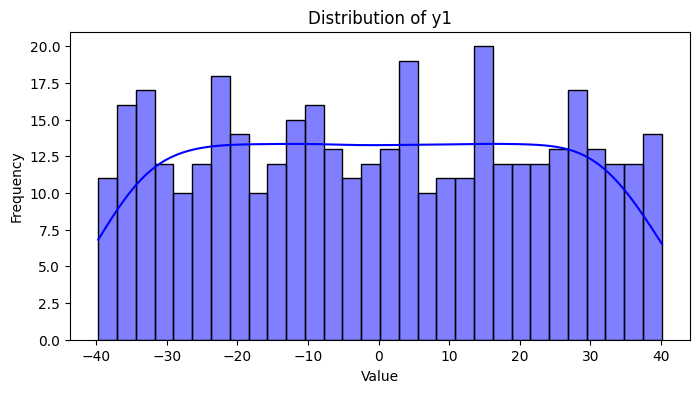

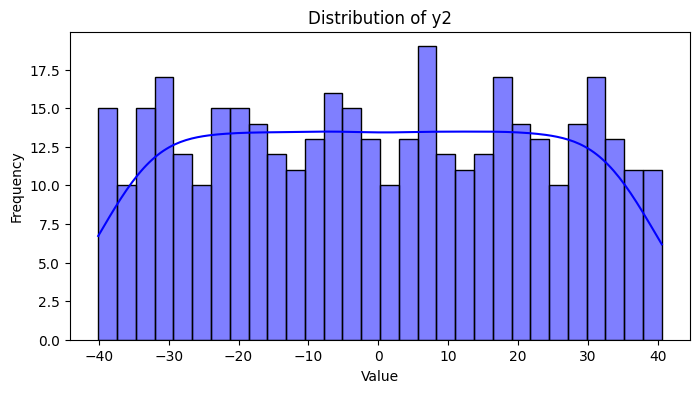

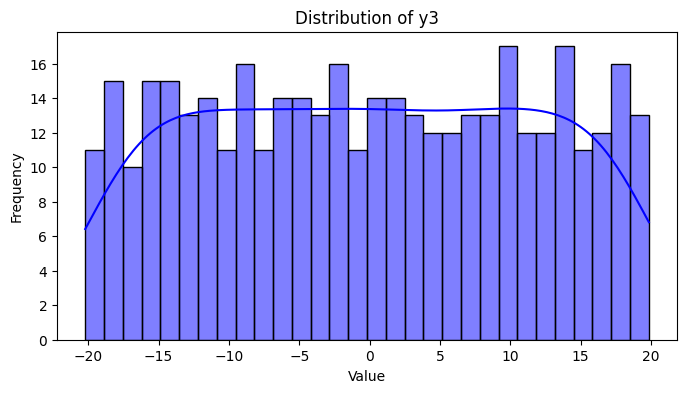

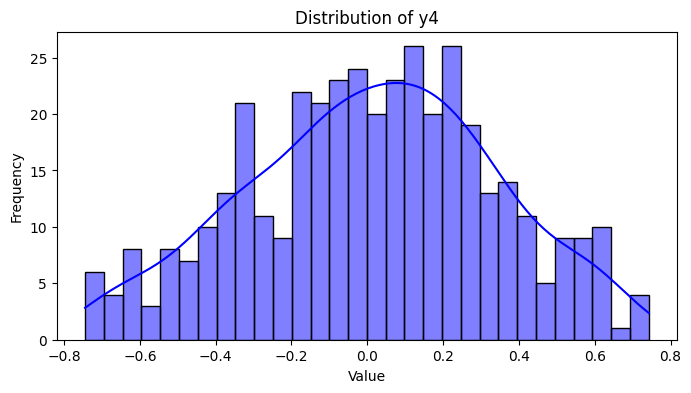

In [ ]:
# Plot histograms and KDE for each Y column
for col in train_df.columns[1:]:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df[col], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

##Outlier detection

In [ ]:
# Function to detect outliers using IQR
def detect_outliers(df):
    outlier_indices = {}
    for col in df.columns[1:]:
        Q1 = np.percentile(df[col], 25)
        Q3 = np.percentile(df[col], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = outliers.index.tolist()
    return outlier_indices

# Detect outliers
outliers = detect_outliers(train_df)
print("Outliers detected in each column:", outliers)

Outliers detected in each column: {'y1': [], 'y2': [], 'y3': [], 'y4': []}


<ipython-input-29-79d65b32a248>:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


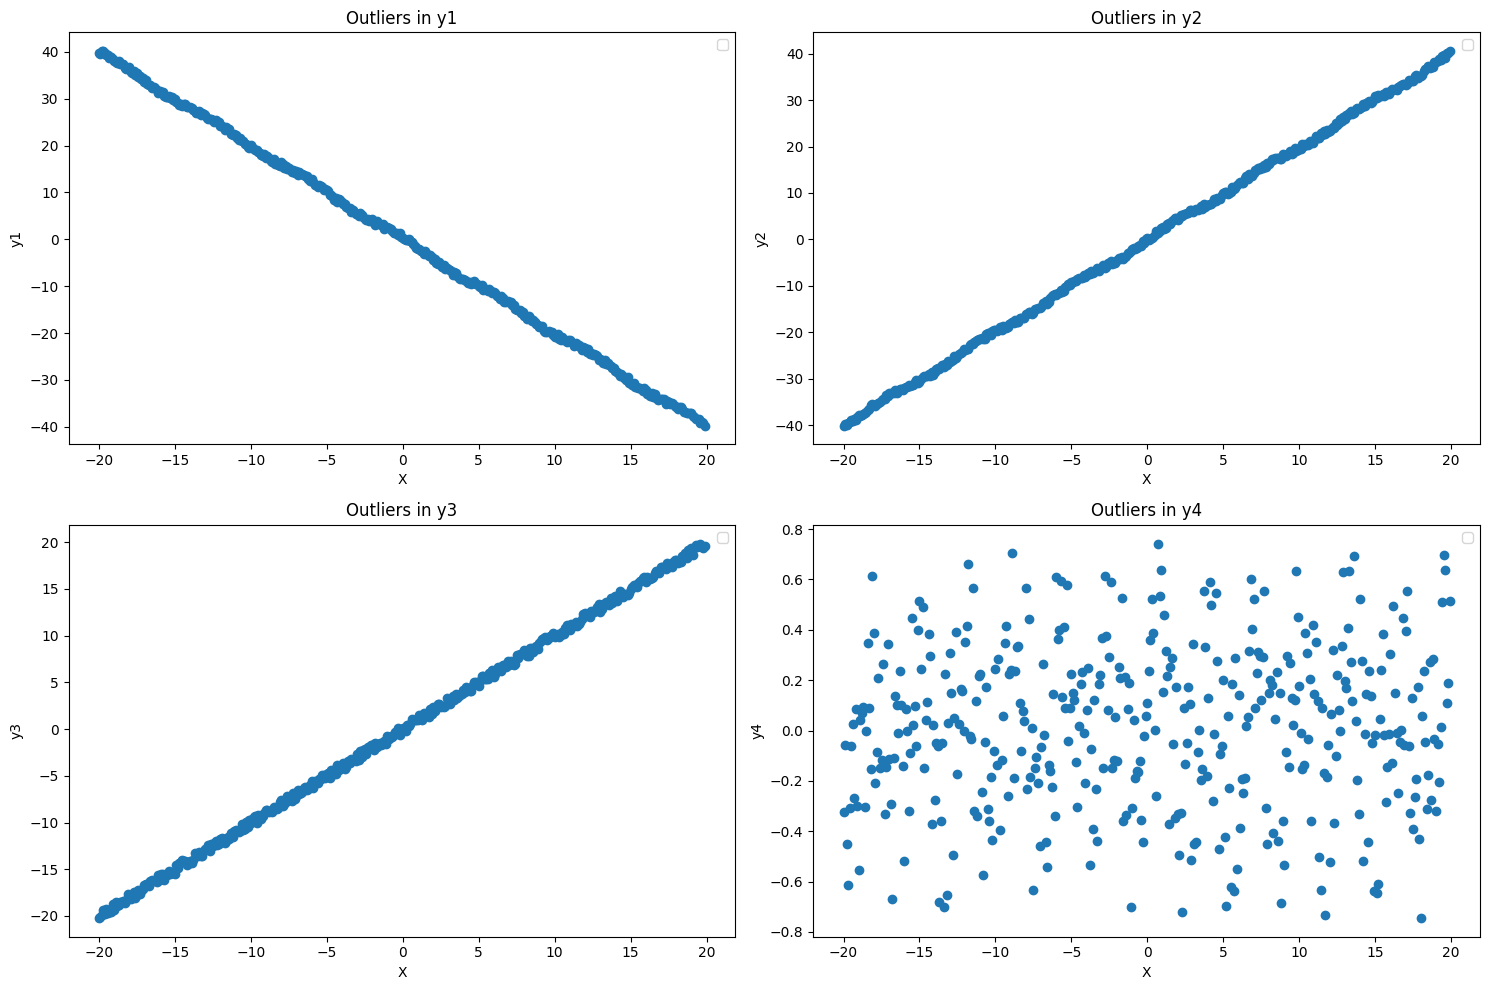

In [29]:
num_plots = len(outliers)
cols = 2
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (col, indices) in enumerate(outliers.items()):
    ax = axes[i]
    ax.scatter(train_df["x"], train_df[col])
    ax.set_title(f"Outliers in {col}")
    ax.set_xlabel("X")
    ax.set_ylabel(col)
    ax.legend()

for j in range(i + 1, len(axes)):
  axes[j].set_visible(False)

plt.tight_layout()
plt.show()

##Correlation analysis

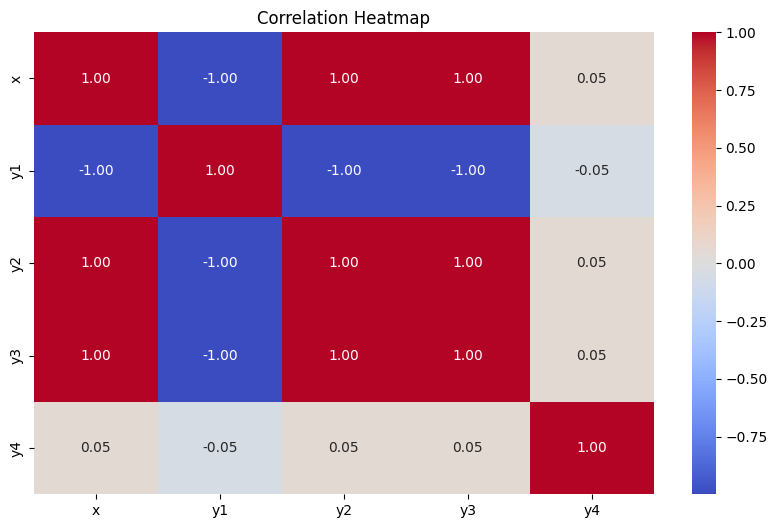

In [ ]:
# Compute correlation matrix
corr_matrix = train_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()